# 01 CIGNN Transformation Experiment

> Detecting (and inverting?) transformations on HW samples

This experiment aims to define a "transformation space" for handwritten symbols. We hypothesize that each symbol has an ideal, undisturbed representation, which is altered during the handwriting process due to transformations and imprecisions, resulting in variations from this ideal form. Additionally, processes such as storage and digitization introduce further modifications, increasing the deviation from the original ideal representation.

Optical Character Recognition (OCR) would be a straightforward task if all symbols appeared in their ideal form. However, it is the transformations and distortions that introduce complexity. To simplify the analysis in this study, we assume that only affine transformations are applied, the symbol is known a priori, and other potential complexities are minimized.

In [2]:
#| default_exp data

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
#| hide
import nbdev; nbdev.nbdev_export()

import os
import pandas as pd

import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.io import read_image
import matplotlib.pyplot as plt

In [5]:
dataset_path = '/data/datasets/saintgalldb-v1.0/saintgalldb-v1.0'

### Step 1: Loading the Saint Gall dataset

The dataset is fairly small, so storing it locally is feasible. The assumed location for the root dataset directory is `/data/datasets/saintgalldb-v1.0/saintgalldb-v1.0`.
From the README file we see that train, test and validation splits are already provided and that normalised line images are also available. To be compatible with the HTR model we will use lines as inputs and modify the synthesis pipeline accordingly. 

The annotation files (train.txt, test.txt, valid.txt) consist of one entry per line indicating the ID of a single 
fullpage image, such as `csg562-003` from `train.txt`. However, we are interested in the lines within that image, 
so it is important to also read the `transcription.txt` file. The transcription file looks like this

```text
  csg562-003-03 r-et|a-m-o-r-e-m-pt|s-i-c-u-t-i|d-e|e-o|p-r-i-u-s-q-u-a-m|n-a-s-c-e-r-et-u-r|p-r-o-v-i-s-u-m|e-e provocaret|amorem|sicuti|de|eo|priusquam|nasceretur|provisum|esse
  a--------- b- c-------------[...]   

  a) ID of the fullpage image
  b) line number within that image
  c) Characters and symbols, separated by "|" into words
  
```

We are using the transcription file as input basis because it does not contain the calligraphic multi-line characters and texts at the beginning of the page or document. Also, the normalised images are available for these lines only. 



In [6]:
#| export
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF


class SaintGallDataset(Dataset):
    """Dataset class for accessing the local Saint Gall Dataset as text lines.

    The samples from this class are the (annotated) normalised line images in binarised form.
    """
    def __init__(self, split_file_path, dataset_root_path="/data/datasets/saintgalldb-v1.0/saintgalldb-v1.0", transform=None, target_transform=None):
        """Set up the dataset class and calculate the number of text lines for the current split.

        The `split_file` parameter is expected to point to either train.txt, test.txt, valid.txt or a custom split file
        of the same format containing a single fullpage-id per line. The line contents and images can then be 
        inferred by relative paths from the dataset root directory.
        """

        self.dataset_root_path = dataset_root_path
        # contains one fullpage img id per entry
        self.split = pd.read_csv(split_file_path)
        
        with open(os.path.join(self.dataset_root_path, "ground_truth", "transcription.txt"), "r") as fh:
            self._transcription = fh.readlines()

        # Now we can filter the transcription to only contain the lines belonging to the current split
        self.transcription = pd.DataFrame([line.split(" ") for line in self._transcription if line.startswith(tuple(self.split))])
        self.img_dir_path = os.path.join(self.dataset_root_path, "data", "line_images_normalized")

        self.transform = transform
        self.target_transform = target_transform
        

    def __len__(self):
        return len(self.transcription)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir_path, self.transcription.iloc[idx, 0] + '.png') 
        _image = read_image(img_path)

        # Since the images have different widths we naively pad them to a safe upper bound of 2000 for now
        
        image = TF.resize(_image, size=(120, 1024))


        label = self.transcription.iloc[idx, 1]
        label = label.replace("-", "").replace("|", " ")
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

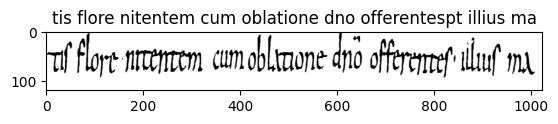

In [7]:
# Test the implementation by loading a sample along with the annotation
from torch.utils.data import DataLoader
ds = SaintGallDataset("/data/datasets/saintgalldb-v1.0/saintgalldb-v1.0/sets/train.txt")
dl = DataLoader(ds, batch_size=16, shuffle=True)

data = next(iter(dl))
plt.imshow(data[0][0][0], cmap='gray', vmin=0, vmax=255)
plt.title(data[1][0])
plt.show()